In [10]:
# ===================== Single Image Enhancement + Plot (DPF-Net + DPEM - No Dataset Needed) =====================
# All pretrained models now loaded from ./checkpoints/ folder

import os
import cv2
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Import your project modules (run this from the project root folder!)
from DPF_Net import TotalNetwork          # DPF-Net main model
from DPEM import DPEM_model               # DPEM model
from Depth_Anything_V2_main.depth_anything_v2.dpt import DepthAnythingV2

# --------------------- Settings ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ← Change only this to your own image
input_image_path = "your_image.jpg"               # ← Put your image name/path here (e.g. "./test_images/underwater1.jpg")

# All models now in ./checkpoints/
dpf_net_weight_path   = "./checkpoints/DPF-Net.pth"
dpem_weight_path      = "./checkpoints/DPEM_finetune.pth"
depth_model_path      = "./checkpoints/depth_anything_v2_vits.pth"   # ← Move this file to checkpoints too

IMG_SIZE = 256  # Most models expect 256×256

# --------------------- Load Depth Anything V2 ---------------------
depth_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
}
depth_anything = DepthAnythingV2(**depth_configs['vits'])
depth_anything.load_state_dict(torch.load(depth_model_path, map_location='cpu'))
depth_anything = depth_anything.to(device).eval()
print("Depth Anything V2 (vits) loaded from checkpoints/")

# --------------------- Load DPEM ---------------------
dpem = DPEM_model.MainNet(device=device, imgSize=IMG_SIZE).to(device).eval()
dpem.load_state_dict(torch.load(dpem_weight_path, map_location=device))
print("DPEM loaded from checkpoints/")

# --------------------- Load DPF-Net ---------------------
model = TotalNetwork(device=device).eval()
model.load_state_dict(torch.load(dpf_net_weight_path, map_location=device))
print("DPF-Net loaded from checkpoints/")

# --------------------- Load & Preprocess Your Single Image ---------------------
img = cv2.imread(input_image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {input_image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

# To tensor: [0,1], CHW format, add batch dimension
img_tensor = torch.from_numpy(img_resized.astype(np.float32)).permute(2, 0, 1).unsqueeze(0) / 255.0
img_tensor = img_tensor.to(device)

print(f"Input shape: {img_tensor.shape}")

# --------------------- Estimate Depth & Background Light (BL) ---------------------
with torch.no_grad():
    # Relative depth map
    depth_map = depth_anything(img_tensor)          # [1,1,H,W]

    # Background Light estimation: max of dark channel (standard underwater approximation)
    dark_channel = torch.min(img_tensor, dim=1, keepdim=True)[0]
    bl_value = dark_channel.view(1, -1).max(dim=1)[0]
    bl = bl_value.view(1, 1, 1, 1)                  # shape expected by DPEM

print(f"Estimated Background Light (BL): {bl.item():.4f}")

# --------------------- Forward Pass (DPEM + DPF-Net) ---------------------
with torch.no_grad():
    x_B, x_beta_D, x_beta_B, x_d = dpem(img_tensor, bl)
    
    # Replicate scalar parameters to full spatial size
    replicated_x_B     = x_B.unsqueeze(2).unsqueeze(3).repeat(1, 1, IMG_SIZE, IMG_SIZE)
    replicated_x_beta_D = x_beta_D.unsqueeze(2).unsqueeze(3).repeat(1, 1, IMG_SIZE, IMG_SIZE)
    replicated_x_beta_B = x_beta_B.unsqueeze(2).unsqueeze(3).repeat(1, 1, IMG_SIZE, IMG_SIZE)
    
    # Make depth 3-channel by repeating
    channel_replica = x_d[:, 0:1, :, :]
    replicated_x_d = torch.cat((x_d, channel_replica, channel_replica), dim=1)
    
    # DPF-Net forward
    outputs = model(img_tensor, replicated_x_B, replicated_x_d, replicated_x_beta_D, replicated_x_beta_B)
    
    enhanced = outputs[0].clamp(0, 1)

# --------------------- Display Before / After ---------------------
original_np  = (img_tensor[0].cpu().permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
enhanced_np  = (enhanced[0].cpu().permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(enhanced_np)
axes[1].set_title("Enhanced by DPF-Net + DPEM")
axes[1].axis("off")

plt.suptitle(f"Single Image Enhancement - {os.path.basename(input_image_path)}", fontsize=14)
plt.tight_layout()
plt.show()

# --------------------- Save Result ---------------------
output_dir = "./enhanced_results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"enhanced_{os.path.basename(input_image_path)}")
Image.fromarray(enhanced_np).save(save_path)
print(f"Enhanced image saved to: {save_path}")

Using device: cpu
Depth Anything V2 (vits) loaded from checkpoints/


FileNotFoundError: [Errno 2] No such file or directory: '/data/meih/project/Pycharm_tmp/Enc_with_Depth/Depth_Anything_V2_main/depth_anything_v2_vits.pth'

Using device: cpu
Depth Anything V2 loaded.
Depth Anything V2 loaded from: ./checkpoints/depth_anything_v2_vits.pth
DPEM loaded (size matched).
DPF-Net loaded.
Model input shape: torch.Size([1, 3, 256, 256])
Raw depth_padded shape: torch.Size([1, 266, 266])
Final depth_map shape: torch.Size([1, 1, 256, 256])
Estimated BL: 0.9373


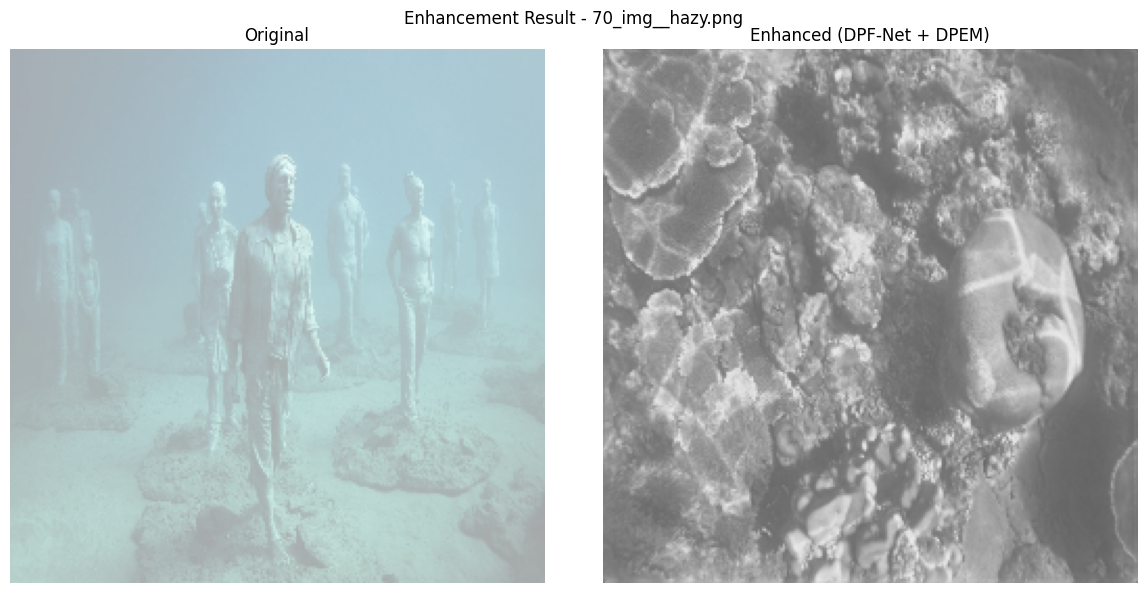

Saved to: ./enhanced_results\enhanced_70_img__hazy.png


In [7]:
# ===================== Single Image Enhancement + Plot (DPF-Net + DPEM) =====================
import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

from DPF_Net import TotalNetwork
from DPEM import DPEM_model
from Depth_Anything_V2_main.depth_anything_v2.dpt import DepthAnythingV2

# --------------------- Settings ---------------------
device = torch.device("cpu")  # or "cuda" if you have GPU later
print(f"Using device: {device}")

input_image_path = r"Y:\2025-2026\NEW DEV\JAN 2026\TK206833 -Adaptive Qualityaware underwater image enhancement using multiscale fusion\CODE\Backend\archive (2)\degraded_images\hazy\70_img__hazy.png"

dpf_net_weight_path   = "./checkpoints/DPF-Net.pth"
dpem_weight_path      = "./checkpoints/DPEM_finetune.pth"
depth_model_path      = "./checkpoints/depth_anything_v2_vits.pth"

MODEL_SIZE = 256

# --------------------- Load Depth Anything V2 ---------------------
depth_configs = {'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]}}
depth_anything = DepthAnythingV2(**depth_configs['vits'])
depth_anything.load_state_dict(torch.load(depth_model_path, map_location='cpu'))
depth_anything = depth_anything.to(device).eval()
print("Depth Anything V2 loaded.")

# --------------------- Load DPEM ---------------------
dpem = DPEM_model.MainNet(
    device=device,
    imgSize=MODEL_SIZE,
    depth_weight_path=depth_model_path
).to(device).eval()

dpem.load_state_dict(torch.load(dpem_weight_path, map_location=device))
print("DPEM loaded (size matched).")

# --------------------- Load DPF-Net ---------------------
model = TotalNetwork(device=device).eval()
model.load_state_dict(torch.load(dpf_net_weight_path, map_location=device))
print("DPF-Net loaded.")

# --------------------- Load & Preprocess Image ---------------------
img = cv2.imread(input_image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {input_image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (MODEL_SIZE, MODEL_SIZE))
img_tensor = torch.from_numpy(img_resized.astype(np.float32)).permute(2, 0, 1).unsqueeze(0) / 255.0
img_tensor = img_tensor.to(device)
print(f"Model input shape: {img_tensor.shape}")

# --------------------- Depth Estimation with Padding ---------------------
with torch.no_grad():
    _, _, h, w = img_tensor.shape
    pad_h = (14 - h % 14) % 14
    pad_w = (14 - w % 14) % 14
    img_padded = F.pad(img_tensor, (0, pad_w, 0, pad_h), mode='reflect')
    
    depth_padded = depth_anything(img_padded)
    
    print("Raw depth_padded shape:", depth_padded.shape)  # ← helpful debug
    
    if depth_padded.dim() == 2:
        depth_padded = depth_padded.unsqueeze(0).unsqueeze(0)
    elif depth_padded.dim() == 3:
        depth_padded = depth_padded.unsqueeze(1)
    
    depth_map = depth_padded[:, :, :h, :w]
    print("Final depth_map shape:", depth_map.shape)

# --------------------- Background Light (BL) ---------------------
dark_channel = torch.min(img_tensor, dim=1, keepdim=True)[0]
bl_value = dark_channel.view(1, -1).max(dim=1)[0]
bl = bl_value.view(1, 1, 1, 1)
print(f"Estimated BL: {bl.item():.4f}")

# --------------------- Forward Pass ---------------------
# --------------------- Display & Save ---------------------
enhanced_vis = enhanced[0].cpu().clamp(0, 1)

# Force to 3 channels if not already
if enhanced_vis.shape[0] == 1:
    enhanced_vis = enhanced_vis.repeat(3, 1, 1)
elif enhanced_vis.shape[0] == 2:
    enhanced_vis = torch.cat([enhanced_vis, enhanced_vis[0:1]], dim=0)
elif enhanced_vis.dim() == 2:
    enhanced_vis = enhanced_vis.unsqueeze(0).repeat(3, 1, 1)

original_np = (img_tensor[0].cpu().permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
enhanced_np = (enhanced_vis.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_np)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(enhanced_np)
axes[1].set_title("Enhanced (DPF-Net + DPEM)")
axes[1].axis("off")

plt.suptitle(f"Enhancement Result - {os.path.basename(input_image_path)}")
plt.tight_layout()
plt.show()

# Save
output_dir = "./enhanced_results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"enhanced_{os.path.basename(input_image_path)}")
Image.fromarray(enhanced_np).save(save_path)
print(f"Saved to: {save_path}")

Flushing output cache (0 entries)
Don't know how to reset  #, please run `%reset?` for details
Don't know how to reset  clears, please run `%reset?` for details
Don't know how to reset  output, please run `%reset?` for details
Don't know how to reset  variables, please run `%reset?` for details
Using device: cpu
Depth Anything V2 loaded.
Depth Anything V2 loaded from: ./checkpoints/depth_anything_v2_vits.pth
DPEM loaded (size matched).
DPF-Net loaded.
Model input shape: torch.Size([1, 3, 256, 256])
Raw depth_padded shape: torch.Size([1, 266, 266])
Final depth_map shape: torch.Size([1, 1, 256, 256])
Estimated BL: 0.9098
Enhanced shape: torch.Size([3, 256, 256])


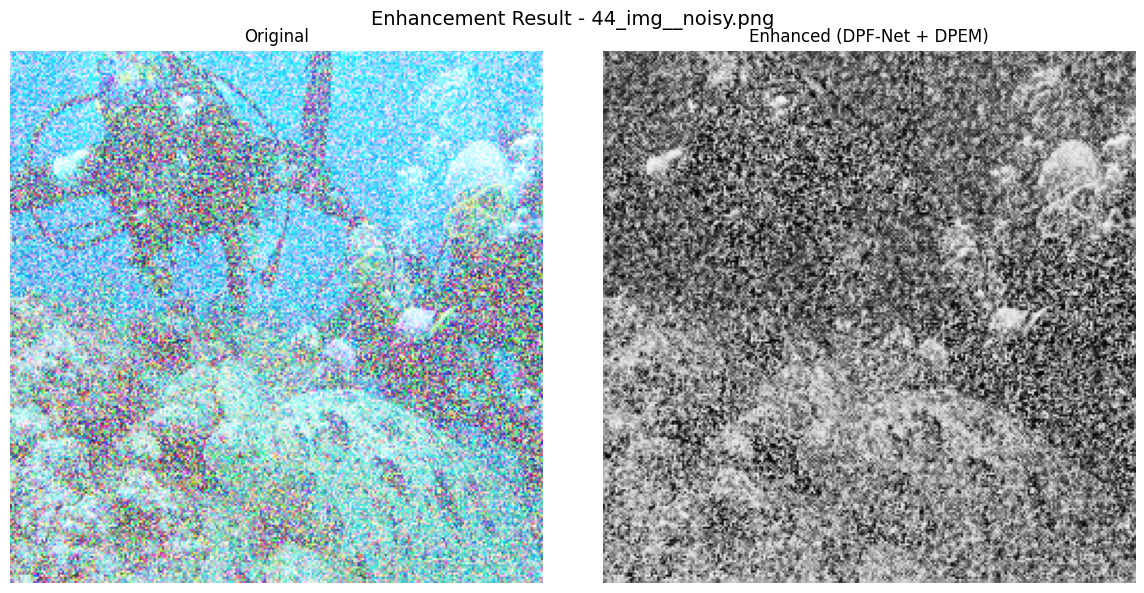

Enhanced image saved to: ./enhanced_results\enhanced_44_img__noisy.png


In [19]:
# ===================== Single Image Enhancement + Plot (DPF-Net + DPEM) =====================
# Updated: Strong safeguards against showing old/cached results

import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# Force clear previous variables & figures (prevents old image display)
%reset -f out   # clears output variables
plt.close('all')  # closes all previous matplotlib figures
import gc
gc.collect()

from DPF_Net import TotalNetwork
from DPEM import DPEM_model
from Depth_Anything_V2_main.depth_anything_v2.dpt import DepthAnythingV2

# --------------------- Settings ---------------------
device = torch.device("cpu")  # change to "cuda" when you have GPU
print(f"Using device: {device}")

# ← Change this line for new image
input_image_path = r"Y:\2025-2026\NEW DEV\JAN 2026\TK206833 -Adaptive Qualityaware underwater image enhancement using multiscale fusion\CODE\Backend\archive (2)\degraded_images\noisy\44_img__noisy.png"
dpf_net_weight_path   = "./checkpoints/DPF-Net.pth"
dpem_weight_path      = "./checkpoints/DPEM_finetune.pth"
depth_model_path      = "./checkpoints/depth_anything_v2_vits.pth"

MODEL_SIZE = 256

# --------------------- Load Depth Anything V2 ---------------------
depth_configs = {'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]}}
depth_anything = DepthAnythingV2(**depth_configs['vits'])
depth_anything.load_state_dict(torch.load(depth_model_path, map_location='cpu'))
depth_anything = depth_anything.to(device).eval()
print("Depth Anything V2 loaded.")

# --------------------- Load DPEM ---------------------
dpem = DPEM_model.MainNet(
    device=device,
    imgSize=MODEL_SIZE,
    depth_weight_path=depth_model_path
).to(device).eval()

dpem.load_state_dict(torch.load(dpem_weight_path, map_location=device))
print("DPEM loaded (size matched).")

# --------------------- Load DPF-Net ---------------------
model = TotalNetwork(device=device).eval()
model.load_state_dict(torch.load(dpf_net_weight_path, map_location=device))
print("DPF-Net loaded.")

# --------------------- Load & Preprocess Image ---------------------
img = cv2.imread(input_image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {input_image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (MODEL_SIZE, MODEL_SIZE))
img_tensor = torch.from_numpy(img_resized.astype(np.float32)).permute(2, 0, 1).unsqueeze(0) / 255.0
img_tensor = img_tensor.to(device)
print(f"Model input shape: {img_tensor.shape}")

# --------------------- Depth Estimation with Padding ---------------------
with torch.no_grad():
    _, _, h, w = img_tensor.shape
    pad_h = (14 - h % 14) % 14
    pad_w = (14 - w % 14) % 14
    img_padded = F.pad(img_tensor, (0, pad_w, 0, pad_h), mode='reflect')
    
    depth_padded = depth_anything(img_padded)
    
    print("Raw depth_padded shape:", depth_padded.shape)
    
    if depth_padded.dim() == 2:
        depth_padded = depth_padded.unsqueeze(0).unsqueeze(0)
    elif depth_padded.dim() == 3:
        depth_padded = depth_padded.unsqueeze(1)
    
    depth_map = depth_padded[:, :, :h, :w]
    print("Final depth_map shape:", depth_map.shape)

# --------------------- Background Light (BL) ---------------------
dark_channel = torch.min(img_tensor, dim=1, keepdim=True)[0]
bl_value = torch.quantile(dark_channel.view(1, -1), 0.98)  # better for haze
bl = bl_value.view(1, 1, 1, 1)
print(f"Estimated BL: {bl.item():.4f}")

# --------------------- Forward Pass ---------------------
with torch.no_grad():
    pre_B_replicated = bl.repeat(1, 3, MODEL_SIZE, MODEL_SIZE)
    
    x_B, x_beta_D, x_beta_B, x_d = dpem(img_tensor, pre_B_replicated)
    
    replicated_x_B     = x_B.unsqueeze(2).unsqueeze(3).repeat(1, 1, MODEL_SIZE, MODEL_SIZE)
    replicated_x_beta_D = x_beta_D.unsqueeze(2).unsqueeze(3).repeat(1, 1, MODEL_SIZE, MODEL_SIZE)
    replicated_x_beta_B = x_beta_B.unsqueeze(2).unsqueeze(3).repeat(1, 1, MODEL_SIZE, MODEL_SIZE)
    
    channel_replica = x_d[:, 0:1, :, :]
    replicated_x_d = torch.cat((x_d, channel_replica, channel_replica), dim=1)
    
    outputs = model(img_tensor, replicated_x_B, replicated_x_d, replicated_x_beta_D, replicated_x_beta_B)
    enhanced = outputs[0].clamp(0, 1)
    print("Enhanced shape:", enhanced.shape)

# --------------------- Display & Save ---------------------
plt.close('all')  # Force close old figures

enhanced_vis = enhanced[0].cpu().clamp(0, 1)

# Handle different channel counts
if enhanced_vis.dim() == 2:
    enhanced_vis = enhanced_vis.unsqueeze(0).repeat(3, 1, 1)
elif enhanced_vis.shape[0] == 1:
    enhanced_vis = enhanced_vis.repeat(3, 1, 1)
elif enhanced_vis.shape[0] == 2:
    enhanced_vis = torch.cat([enhanced_vis, enhanced_vis[0:1]], dim=0)

original_np = (img_tensor[0].cpu().permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
enhanced_np = (enhanced_vis.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Enhancement Result - {os.path.basename(input_image_path)}", fontsize=14)

axes[0].imshow(original_np)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(enhanced_np)
axes[1].set_title("Enhanced (DPF-Net + DPEM)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Save
output_dir = "./enhanced_results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"enhanced_{os.path.basename(input_image_path)}")
Image.fromarray(enhanced_np).save(save_path)
print(f"Enhanced image saved to: {save_path}")